# Pipeline Stage-by-Stage Debugger

A debugging notebook where **each pipeline sub-step gets its own cell** so
we can inspect each intermediate step in isolation — before moving to the next cell. This helps us understand how the method works, how different steps in the process impact the results, and diagnose and resolve any issues.

Every cell calls `inspect()`, which:
1. Runs the same three formal QA checks (`all_nan`, `out_of_range`,
   `sporadic_nan_days`) from `srm.qa_checks` — the same checks a
   `bcsd qa` run applies to a cached artifact.
2. Prints a PASS/FAIL verdict per check.
3. Plots a spatial map (`time=0`) and a domain-mean time series.
4. Registers the computed array in the `STEPS` dict so the cross-stage
   evolution plots at the bottom can iterate over every step.



In [1]:
import textwrap
import warnings

import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterix  # noqa: F401  # registers .proj/.rio accessors
import xarray as xr
import xarray_regrid  # noqa: F401  # registers .regrid namespace

from srm.bcsd_config import BCSDConfig, PipelineOptions, VariableConfig
from srm.downscaling_utils import (
    get_historical_experiment,
    get_obs,
    interpolate_fine_to_coarse_grid,
    subset_space,
)
from srm.lineage import resolve_member_lineage
from srm.pipeline import BCSDPipeline
from srm.qa_checks import _STATUS_SYMBOL, run_artifact_checks
from srm.utils import open_icechunk
from srm.validation import CheckStatus

warnings.filterwarnings("ignore", category=FutureWarning)


def _step_title(step: str, width: int = 16) -> str:
    """Wrap a snake_case step name to fit in a narrow subplot title."""
    return textwrap.fill(step.replace("_", " "), width=width)

## Config

**Edit only this cell** between debug runs. Set `SCENARIO = None` to debug
Stage 1 + Stage 2 only; set a scenario string to also exercise Stage 3.

`scratch_dir` and `output_dir` point to a local tmp directory so no debug
writes touch the real S3 cache.


In [2]:
# ── Edit these values ──────────────────────────────────────────────────────────
GCM = "CESM2-WACCM"
VARIABLE = "pr"
ENSEMBLE_MEMBER = "003"  # CESM2-WACCM SSP245/G6-1.5K uses numeric IDs; "001" → hist r1i1p1f1
SCENARIO = "SSP245"  # None → Stage 1+2 only; set e.g. "SSP245" / "G6-1.5K" to also exercise Stage 3

# Southern Africa including high spot in Angola.
# (lat_min, lat_max, lon_min, lon_max)
# SUBSET_BOUNDS = (15,25, 70,80) # 32 secs for prep obesrvations, 10 sec for training historical
SUBSET_BOUNDS = (-67, 67, -180, 180)
# Override rsds's default debias_approach ("nonparametric_hybrid_2sided") with
# plain "nonparametric" — keeps every other rsds setting (downscaling_method,
# downscaling_clim_method, ...) from VariableConfig.for_variable() as-is.
debiasing_approach = "nonparametric"  # "nonparametric"
variable_config = VariableConfig.for_variable(VARIABLE).model_copy(
    update={"debias_approach": debiasing_approach}
)
# ──────────────────────────────────────────────────────────────────────────────

config = BCSDConfig(
    gcm=GCM,
    variable=VARIABLE,
    ensemble_member=ENSEMBLE_MEMBER,
    scenario=SCENARIO,
    # predict_period_start must equal the scenario data start (2015 for SSP245)
    # so stitch_historical_scenario produces a gap-free 1978–end timeseries.
    predict_period_start=2015 if SCENARIO else None,
    predict_period_end=2060 if SCENARIO else None,
    subset_bounds=SUBSET_BOUNDS,
    variable_config=variable_config,
)
options = PipelineOptions(
    scratch_dir="/tmp/bcsd-debug/scratch/",  # local — never touches S3
    output_dir="/tmp/bcsd-debug/output/",
    branch="debug",
    environment="debug",
)
pipeline = BCSDPipeline(config, options)
print(f"Run: {config.run_id}")
print(f"Subset bounds: {config.subset_bounds}")
print(f"Scenario: {config.scenario!r}")
print(f"Predict period: {config.predict_period_start}–{config.predict_period_end}")
print(f"Debias approach: {config.variable_config.debias_approach}")

Run: CESM2-WACCM_pr_003_SSP245_subset
Subset bounds: (-67.0, 67.0, -180.0, 180.0)
Scenario: 'SSP245'
Predict period: 2015–2060
Debias approach: nonparametric


In [3]:
inspect_variables = False

## Inspection helper

`inspect(da, stage)` is called after every sub-step. It:
- `.compute()`s the DataArray (fine for the small subset region)
- Runs `run_artifact_checks()` (skipped for arrays with a `dayofyear` dim
  instead of a `time` dim, since those lack the time axis the checks need)
- Prints a PASS/FAIL line per check with detail for any non-PASS result
- Plots spatial map + domain-mean series
- Registers `da` in `STEPS` and its NaN fraction in `STEP_NAN_FRACTIONS`


In [4]:
STEPS: dict[str, xr.DataArray] = {}  # ordered; keys = step labels
STEP_NAN_FRACTIONS: dict[str, float] = {}  # per-step nan_fraction for bar chart


def inspect(
    da: xr.DataArray,
    stage: str,
    *,
    skip_qa: bool = False,
) -> xr.DataArray:
    """Compute, QA-check, plot, and register a pipeline intermediate."""
    print(f"\n{'=' * 60}")
    print(f"  {stage}")
    print(f"{'=' * 60}")

    da = da.compute()
    STEPS[stage] = da

    has_time = "time" in da.dims
    has_doy = "dayofyear" in da.dims

    # ── QA checks ─────────────────────────────────────────────────────────────
    if not skip_qa and has_time:
        results = run_artifact_checks(
            da,
            gcm=config.gcm,
            variable=config.variable,
            ensemble_member=config.ensemble_member,
            scenario=config.scenario,
            stage=stage,
        )
        STEP_NAN_FRACTIONS[stage] = results["all_nan"].nan_fraction
        for check_name, result in results.items():
            sym = _STATUS_SYMBOL[result.status]
            line = f"  {sym} {check_name}: {result.status.upper()}"
            if result.message:
                line += f" — {result.message}"
            print(line)
            if result.status not in (CheckStatus.PASS, CheckStatus.SKIP) and result.detail:
                for k, v in result.detail.items():
                    print(f"        {k}: {v}")
    elif has_doy:
        print("  (QA checks skipped — dayofyear dimension, no time axis)")
    else:
        print("  (QA checks skipped)")

    # ── Summary ───────────────────────────────────────────────────────────────
    print(f"  shape: {dict(da.sizes)}")
    if has_time or has_doy:
        nan_frac = float(np.isnan(da.values).mean())
        print(f"  NaN:   {nan_frac:.4f} ({nan_frac * 100:.2f}%)")

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(stage, fontsize=12, fontweight="bold")
    try:
        if has_time:
            da.isel(time=0).plot(ax=axes[0], add_colorbar=True)
            axes[0].set_title("time=0 (spatial map)")
            da.mean(["lat", "lon"]).plot(ax=axes[1])
            axes[1].set_title("domain-mean time series")
        elif has_doy:
            da.isel(dayofyear=0).plot(ax=axes[0], add_colorbar=True)
            axes[0].set_title("dayofyear=0 (spatial map)")
            da.mean(["lat", "lon"]).plot(ax=axes[1])
            axes[1].set_title("domain-mean DOY series")
        else:
            for ax in axes:
                ax.text(0.5, 0.5, "no time/dayofyear dim", transform=ax.transAxes, ha="center")
    except Exception as exc:
        for ax in axes:
            ax.text(
                0.5,
                0.5,
                f"plot error:\n{exc}",
                transform=ax.transAxes,
                ha="center",
                fontsize=8,
                wrap=True,
            )
    plt.tight_layout()
    plt.show()
    return da

## ERA5-relative exceedance helpers

Adapted from `synced/notebooks/check_reasonable_ranges.ipynb`. Unlike the
global physical-bounds check in `qa_checks.py`, these compare the downscaled
output against ERA5's **per-pixel** historical min/max — so a value that is
physically plausible globally but implausible at that specific location is
still flagged.

`obs_fine_s2` / `obs_fine_s3` (already in memory) serve as the ERA5
reference, so no extra S3 reads are needed.


In [5]:
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    _HAS_CARTOPY = True
except ImportError:
    _HAS_CARTOPY = False

_MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Grey for zero exceedances; continuous Reds for nonzero — makes clean regions
# immediately obvious without needing a separate mask plot.
_EXCEEDANCE_CMAP = plt.cm.Reds.copy()
_EXCEEDANCE_CMAP.set_under("lightgrey")


def _era5_threshold(obs_fine: xr.DataArray, direction: str, period: str) -> xr.DataArray:
    """Per-pixel ERA5 min/max from obs_fine already in memory.

    Parameters
    ----------
    obs_fine : already-computed fine-grid ERA5 DataArray
    direction : "gt" → max threshold; "lt" → min threshold
    period    : "annual" or "monthly"
    """
    fn = "max" if direction == "gt" else "min"
    if period == "annual":
        return getattr(obs_fine, fn)("time").compute()
    return getattr(obs_fine.groupby("time.month"), fn)("time").compute()


def _count_exceedances(
    da: xr.DataArray,
    threshold: xr.DataArray,
    direction: str,
    period: str,
) -> xr.DataArray:
    """Number of time steps per pixel that exceed the given threshold."""
    if period == "annual":
        mask = da > threshold if direction == "gt" else da < threshold
        return mask.sum("time").compute()
    counts = []
    for m, group in da.groupby("time.month"):
        exceeded = (
            group > threshold.sel(month=m) if direction == "gt" else group < threshold.sel(month=m)
        )
        counts.append(exceeded.sum("time").expand_dims(month=[m]))
    return xr.concat(counts, dim="month").compute()


def _plot_map(da, ax, title, **kw):
    """Single-panel map with optional cartopy coastlines."""
    proj_kw = {"transform": ccrs.PlateCarree()} if _HAS_CARTOPY else {}
    da.plot(ax=ax, **kw, **proj_kw)
    if _HAS_CARTOPY:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_title(title, fontsize=9)


def plot_time_extremes(da: xr.DataArray, label: str) -> None:
    """2×2 grid: time-min and time-max with default and robust color scaling."""
    proj = dict(projection=ccrs.PlateCarree()) if _HAS_CARTOPY else {}
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), subplot_kw=proj)
    fig.suptitle(f"{label} — time extremes", fontweight="bold")
    _plot_map(da.min("time"), axes[0, 0], "time min")
    _plot_map(da.max("time"), axes[0, 1], "time max")
    _plot_map(da.min("time"), axes[1, 0], "time min (robust)", robust=True)
    _plot_map(da.max("time"), axes[1, 1], "time max (robust)", robust=True)
    plt.tight_layout()
    plt.show()


def check_era5_exceedances(
    da: xr.DataArray,
    obs_fine: xr.DataArray,
    label: str,
    period: str = "annual",
) -> None:
    """Flag pixels where da ever exceeds ERA5's per-pixel historical min/max.

    Prints pixel counts and plots exceedance maps (grey = clean, Reds = flagged).
    Set period="monthly" for a 3×4 faceted map — slower but more granular.
    """
    print(f"\n── ERA5-relative exceedance: {label} ({period}) ──")
    n_pixels = int(da.isel(time=0).size)

    for direction, label_suffix in [("gt", "days > ERA5 max"), ("lt", "days < ERA5 min")]:
        thresh = _era5_threshold(obs_fine, direction, period)
        count = _count_exceedances(da, thresh, direction, period)

        n_flagged = int((count > 0).sum().values)
        pct = n_flagged / n_pixels
        sym = "✗" if n_flagged > 0 else "✓"
        print(f"  {sym} {label_suffix}: {n_flagged}/{n_pixels} pixels flagged ({pct:.1%})")

        proj = dict(projection=ccrs.PlateCarree()) if _HAS_CARTOPY else {}
        if period == "annual":
            fig, ax = plt.subplots(figsize=(8, 5), subplot_kw=proj)
            _plot_map(count, ax, f"{label}\n{label_suffix}", cmap=_EXCEEDANCE_CMAP, vmin=0.5)
            plt.tight_layout()
            plt.show()
        else:
            fig, axes = plt.subplots(3, 4, figsize=(20, 10), subplot_kw=proj)
            fig.suptitle(f"{label}\n{label_suffix}", fontsize=11)
            for i, ax in enumerate(axes.flat):
                _plot_map(
                    count.sel(month=i + 1),
                    ax,
                    _MONTH_NAMES[i],
                    cmap=_EXCEEDANCE_CMAP,
                    vmin=0.5,
                )
            plt.tight_layout()
            plt.show()

## Stage 1 — `prepare_observations`

Replicates the internals of `BCSDPipeline.prepare_observations` step by step. The final cell writes the result to the debug cache so Stage 2's `_load_gcm_obs()` can find it.


In [6]:
# ── obs_fine: fine-resolution ERA5 observations ───────────────────────────────
obs_fine = get_obs(var=config.variable, dataset_name=config.obs_dataset)
obs_fine = obs_fine.drop_vars("spatial_ref", errors="ignore")
if config.subset_bounds:
    lat_min, lat_max, lon_min, lon_max = config.subset_bounds
    obs_fine = subset_space(obs_fine, lat_bounds=(lat_min, lat_max), lon_bounds=(lon_min, lon_max))
train_slice = slice(str(config.train_period_start), str(config.train_period_end))
obs_fine = obs_fine.sel(time=train_slice)
if inspect_variables:
    obs_fine = inspect(obs_fine, "obs_fine")

In [7]:
# ── model_grid: GCM historical run (used only as a coarse grid template) ──────
model_grid = get_historical_experiment(
    gcm=config.gcm, member=pipeline._hist_member, var=config.variable
)
model_grid = model_grid.drop_vars("spatial_ref", errors="ignore")
if config.subset_bounds:
    lat_min, lat_max, lon_min, lon_max = config.subset_bounds
    model_grid = subset_space(
        model_grid, lat_bounds=(lat_min, lat_max), lon_bounds=(lon_min, lon_max)
    )
model_grid = model_grid.sel(time=train_slice)

In [8]:
# ── obs_coarse: ERA5 obs regridded to the GCM coarse grid ─────────────────────
obs_coarse_stage1 = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine, da_coarse_grid=model_grid
)
if inspect_variables:
    obs_coarse_stage1 = inspect(obs_coarse_stage1, "obs_coarse_stage1")

In [9]:
%%time
# ── Write to debug cache so Stage 2 _load_gcm_obs() can find obs_regridded ───
# This is equivalent to running prepare_observations() but on the debug branch.
# force=True overwrites any previous debug-branch artifact.
print("Writing obs_coarse to debug cache via prepare_observations(force=True) ...")
prepare_obs_path = pipeline.prepare_observations(force=True)
print(f"  → {prepare_obs_path}")

Writing obs_coarse to debug cache via prepare_observations(force=True) ...


  2026-08-08T00:38:31.459171Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324

  2026-08-08T00:38:31.852272Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324



  → /tmp/bcsd-debug/scratch/debug/CESM2-WACCM-ERA5-lat-67.0to67.0_lon-180.0to180.0.icechunk
CPU times: user 5min 46s, sys: 1min 29s, total: 7min 15s
Wall time: 34.1 s


## Stage 2 — `fit_historical` (debiasing + spatial downscaling)


In [10]:
%%time
# ── _load_gcm_obs: reload from debug cache + load obs_fine, model_hist ────────
obs_coarse, obs_fine_s2, model_hist = pipeline._load_gcm_obs()
if inspect_variables:
    obs_coarse = inspect(obs_coarse, "obs_coarse")
    obs_fine_s2 = inspect(obs_fine_s2, "obs_fine_s2")
    model_hist = inspect(model_hist, "model_hist")

  2026-08-08T00:39:05.515607Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324

  2026-08-08T00:39:05.516546Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324



CPU times: user 94.9 ms, sys: 6.15 ms, total: 101 ms
Wall time: 343 ms


In [11]:
%%time
# ── _apply_bias_correction: ibicus QuantileMapping on historical period ────────
# It calls .values / .load() internally so it is always eager; runtime ~ 1–5 min
# on the South Africa subset.
debiased_coarse = pipeline._apply_bias_correction(obs_coarse, model_hist)
if inspect_variables:
    debiased_coarse = inspect(debiased_coarse, "debiased_coarse")

CPU times: user 16.5 s, sys: 21.7 s, total: 38.1 s
Wall time: 1min 56s


## Stage 3 — `transform_scenario`

Cells below run only when `SCENARIO` is set in the config cell. Run
`pipeline.fit_historical(force=True)` (the optional cell at the end of
Stage 2) before executing these cells, so the historical artifact exists in
the debug cache and `_load_scenario_data()` can validate its dependency.


In [12]:
if config.scenario is None:
    raise RuntimeError(
        "SCENARIO is None. Set SCENARIO in the config cell and re-run "
        "from the top before executing Stage 3 cells."
    )

In [13]:
%%time
# ── _load_scenario_data ────────────────────────────────────────────────────────
(
    obs_coarse_s3,
    obs_fine_s3,
    model_hist_s3,
    model_scenario,
    ssp_timeseries,
) = pipeline._load_scenario_data()

if inspect_variables:
    obs_coarse_s3 = inspect(obs_coarse_s3, "obs_coarse_s3")
    obs_fine_s3 = inspect(obs_fine_s3, "obs_fine_s3")
    model_hist_s3 = inspect(model_hist_s3, "model_hist_s3")
    model_scenario = inspect(model_scenario, "model_scenario")
if ssp_timeseries is not None:
    ssp_timeseries = inspect(ssp_timeseries, "ssp_timeseries")

  2026-08-08T00:41:02.372742Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324

  2026-08-08T00:41:02.373815Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324

  2026-08-08T00:41:02.373882Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324



CPU times: user 109 ms, sys: 15.4 ms, total: 124 ms
Wall time: 406 ms


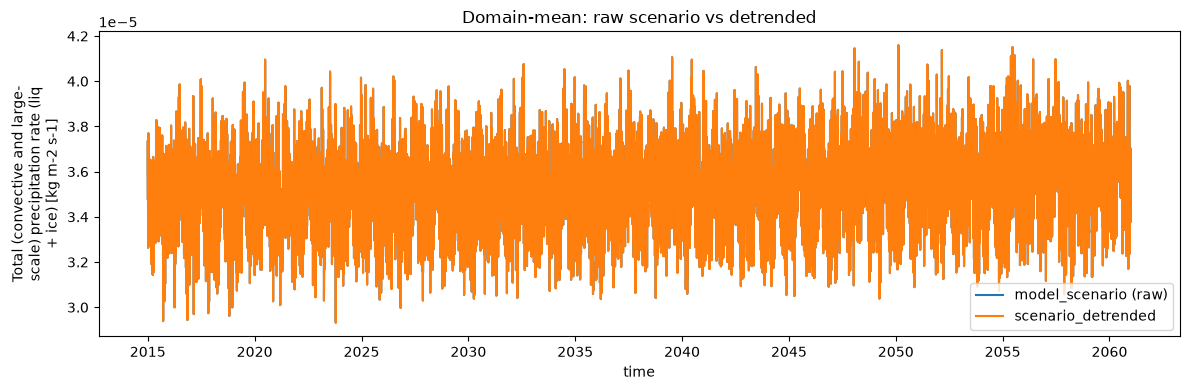

In [14]:
# ── _detrend_scenario ──────────────────────────────────────────────────────────
scenario_detrended, scenario_trend = pipeline._detrend_scenario(
    model_hist_s3, model_scenario, ssp_timeseries
)
if inspect_variables:
    scenario_detrended = inspect(scenario_detrended, "scenario_detrended")
if scenario_trend is not None:
    scenario_trend = inspect(scenario_trend, "scenario_trend")

# Visual comparison: detrended vs raw scenario to confirm detrending direction.
fig, ax = plt.subplots(figsize=(12, 4))
model_scenario.mean(["lat", "lon"]).plot(ax=ax, label="model_scenario (raw)")
scenario_detrended.mean(["lat", "lon"]).plot(ax=ax, label="scenario_detrended")
ax.legend()
ax.set_title("Domain-mean: raw scenario vs detrended")
plt.tight_layout()
plt.show()

In [15]:
%%time
# ── _apply_bias_correction_scenario ───────────────────────────────────────────
scenario_debiased = pipeline._apply_bias_correction_scenario(
    obs_coarse_s3, model_hist_s3, scenario_detrended
)
if inspect_variables:
    scenario_debiased = inspect(scenario_debiased, "scenario_debiased")

CPU times: user 25.7 s, sys: 32.9 s, total: 58.7 s
Wall time: 2min 9s


In [ ]:
# when using 2-sided non-parametric hybrid

In [ ]:
focus_lat, focus_lon = 18, 74.5

In [ ]:
# ── Point time series by day of year ──────────────────────────────────────────
# Every timestep at the focus point, plotted at its calendar day-of-year and
# colored by year — reveals the seasonal cycle and any inter-annual drift
# (a warming/brightening trend shows as later years sitting above earlier
# years at the same day of year).
pt = scenario_debiased.sel(lat=focus_lat, lon=focus_lon, method="nearest").compute()
doy = pt["time"].dt.dayofyear
year = pt["time"].dt.year

_month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]

fig, ax = plt.subplots(figsize=(12, 5))
sc = ax.scatter(doy, pt.values, c=year, cmap="viridis", s=6, alpha=0.6, edgecolors="none")
fig.colorbar(sc, ax=ax, label="year")
ax.set_xticks(_month_starts)
ax.set_xticklabels(_MONTH_NAMES)
ax.set_xlim(1, 366)
ax.set_xlabel("day of year")
ax.set_ylabel(config.variable)
ax.set_title(
    f"scenario_debiased @ lat={float(pt.lat):.2f}, lon={float(pt.lon):.2f} — "
    f"{pt.sizes['time']} timesteps by day of year"
)
plt.tight_layout()
plt.show()

In [ ]:
# when using non-parametric

In [ ]:
# ── Point time series by day of year ──────────────────────────────────────────
# Every timestep at the focus point, plotted at its calendar day-of-year and
# colored by year — reveals the seasonal cycle and any inter-annual drift
# (a warming/brightening trend shows as later years sitting above earlier
# years at the same day of year).
pt = scenario_debiased.sel(lat=focus_lat, lon=focus_lon, method="nearest").compute()
doy = pt["time"].dt.dayofyear
year = pt["time"].dt.year

_month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]

fig, ax = plt.subplots(figsize=(12, 5))
sc = ax.scatter(doy, pt.values, c=year, cmap="viridis", s=6, alpha=0.6, edgecolors="none")
fig.colorbar(sc, ax=ax, label="year")
ax.set_xticks(_month_starts)
ax.set_xticklabels(_MONTH_NAMES)
ax.set_xlim(1, 366)
ax.set_xlabel("day of year")
ax.set_ylabel(config.variable)
ax.set_title(
    f"scenario_debiased @ lat={float(pt.lat):.2f}, lon={float(pt.lon):.2f} — "
    f"{pt.sizes['time']} timesteps by day of year"
)
plt.tight_layout()
plt.show()

In [18]:
subset_string = (
    str(SUBSET_BOUNDS).replace(" ", "_").replace("(", "").replace(")", "").replace(",", "")
)

In [19]:
debiased_coarse.to_dataset(name="pr").to_zarr(
    f"s3://carbonplan-scratch/srm/debiased_coarse-{VARIABLE}-{debiasing_approach}_{subset_string}.zarr"
)
scenario_debiased.to_dataset(name="pr").to_zarr(
    f"s3://carbonplan-scratch/srm/scenario_debiased-{VARIABLE}-{debiasing_approach}_{subset_string}.zarr"
)

/opt/coiled/env/lib/python3.13/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [ ]:
# load in prod run

In [22]:
# --- Run identity (from configs/production/cesm2-waccm/cesm2-waccm-ssp245-std.yaml) ---
gcm = "CESM2-WACCM"
obs_dataset = "ERA5"
scenario = "ssp245"  # icechunk group name (SCENARIO_TO_GROUP["SSP245"])
ensemble_member = "003"
var = "pr"

# --- Data source ---
path_output = (
    "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling"
    f"/output/production/{gcm}-{obs_dataset}-global.icechunk"
)
branch = "v0.13.0"  # icechunk branch; must match a real branch (checked below)

In [23]:
bucket, prefix = path_output.replace("s3://", "").rstrip("/").split("/", 1)
repo = icechunk.Repository.open(
    icechunk.s3_storage(bucket=bucket, prefix=prefix, region="us-west-2")
)
print("Available branches:", repo.list_branches())
assert branch in repo.list_branches(), f"branch {branch!r} not found"

Available branches: {'v0.13.0', 'main', 'v0.12.0'}


In [24]:
# Historical and scenario debiased_coarse are separate runs keyed by different
# ensemble-member IDs; resolve the historical member from the lineage table
# rather than hardcoding it.
hist_member = resolve_member_lineage(
    gcm=gcm, scenario="SSP245", ensemble_member=ensemble_member, variable=var
).historical
print("historical member:", hist_member)

historical member: r3i1p1f1


In [25]:
prod_debiased_coarse_hist = open_icechunk(
    path=path_output,
    branch=branch,
    group=f"debiased_coarse/historical/{var}/{hist_member}",
)[var]

prod_debiased_coarse_ssp245 = open_icechunk(
    path=path_output,
    branch=branch,
    group=f"debiased_coarse/{scenario}/{var}/{ensemble_member}",
)[var]

print(prod_debiased_coarse_hist.time.min().values, "-", prod_debiased_coarse_hist.time.max().values)
print(
    prod_debiased_coarse_ssp245.time.min().values,
    "-",
    prod_debiased_coarse_ssp245.time.max().values,
)

1978-01-01T00:00:00.000000000 - 2014-12-31T00:00:00.000000000
2015-01-01T00:00:00.000000000 - 2099-12-31T00:00:00.000000000


In [26]:
prod_debiased_coarse = xr.concat(
    [prod_debiased_coarse_hist, prod_debiased_coarse_ssp245], dim="time"
).sortby("time")
prod_debiased_coarse

<xarray.DataArray 'pr' (time: 44560, lat: 192, lon: 288)> Size: 10GB
dask.array<getitem, shape=(44560, 192, 288), dtype=float32, chunksize=(8000, 8, 16), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 356kB 1978-01-01 1978-01-02 ... 2099-12-31
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB -180.0 -178.8 -177.5 -176.2 ... 176.2 177.5 178.8

Text(0.5, 1.0, 'CESM2-WACCM ssp245 pr (ens 003) -- debiased_coarse, domain mean')

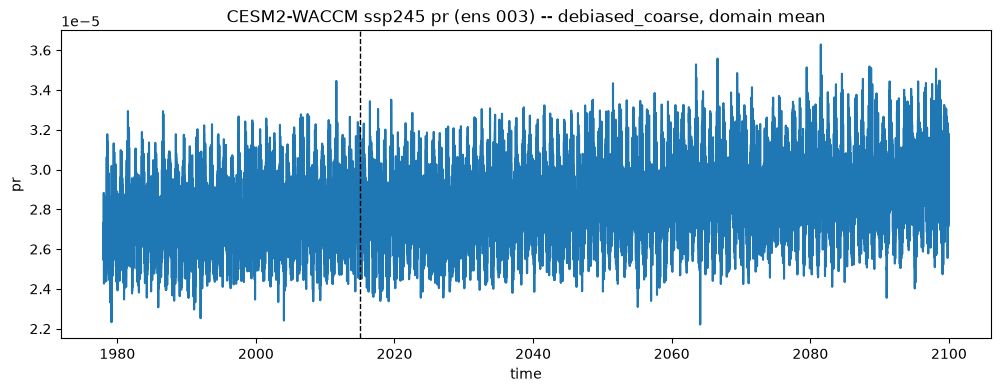

In [27]:
prod_debiased_coarse.mean(["lat", "lon"]).plot(figsize=(12, 4))
plt.axvline(pd.Timestamp("2015-01-01"), color="k", linestyle="--", linewidth=1)
plt.title(f"{gcm} {scenario} {var} (ens {ensemble_member}) -- debiased_coarse, domain mean")

In [29]:
nonparametric = xr.concat([debiased_coarse, scenario_debiased], dim="time")

almost everywhere has at least one day that is impacted by this change

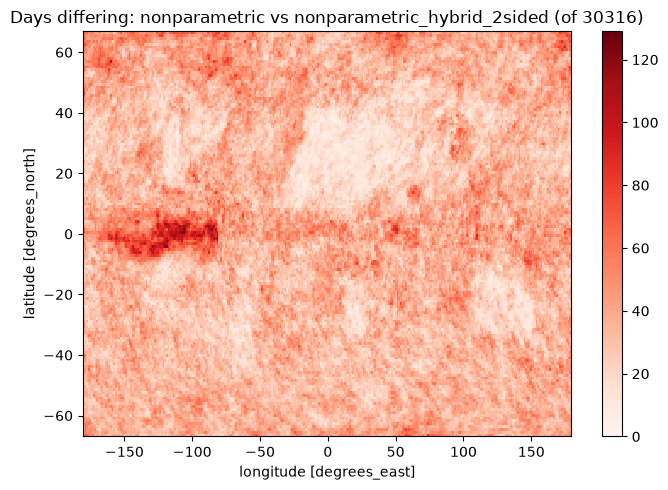

In [30]:
# ── 1. Number of days that differ between the two debias approaches ───────────
# Reuse _EXCEEDANCE_CMAP (grey for 0, Reds for >0) so pixels with no differing
# days read as clean at a glance instead of blending into the low end of Reds.

n_diff = (nonparametric != prod_debiased_coarse).sum(dim="time")
fig, ax = plt.subplots(figsize=(7, 5))
n_diff.plot(ax=ax, cmap=_EXCEEDANCE_CMAP, vmin=1e-9)
ax.set_title(
    f"Days differing: nonparametric vs nonparametric_hybrid_2sided (of {nonparametric.sizes['time']})"
)
plt.tight_layout()
plt.show()

places that are impacted by it about once a year or more

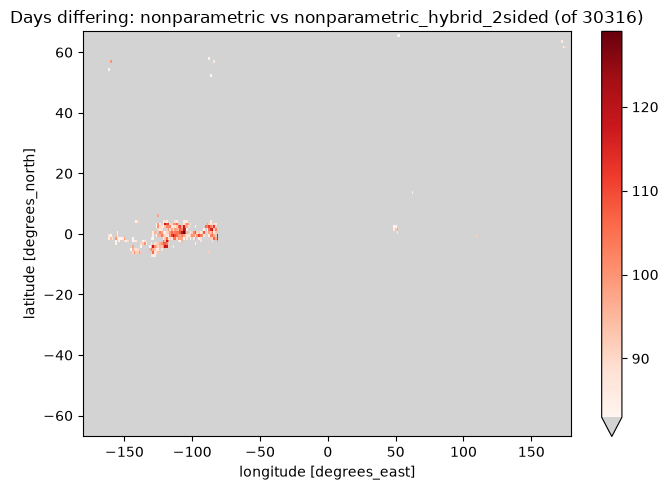

In [31]:
n_diff = (nonparametric != prod_debiased_coarse).sum(dim="time")
fig, ax = plt.subplots(figsize=(7, 5))
# 83 corresponds to once a year for the historical+ssp245 run evaluated here.
n_diff.plot(ax=ax, cmap=_EXCEEDANCE_CMAP, vmin=83)
ax.set_title(
    f"Days differing: nonparametric vs nonparametric_hybrid_2sided (of {nonparametric.sizes['time']})"
)
plt.tight_layout()
plt.show()

In [33]:
# ── 2. Max, mean, and std of the difference (nonparametric − hybrid_2sided) ───
def diff_max(a, b):
    return (a - b).max("time")


def diff_min(a, b):
    return (a - b).min("time")


def diff_mean(a, b):
    return (a - b).mean("time")


def diff_std(a, b):
    return (a - b).std("time")

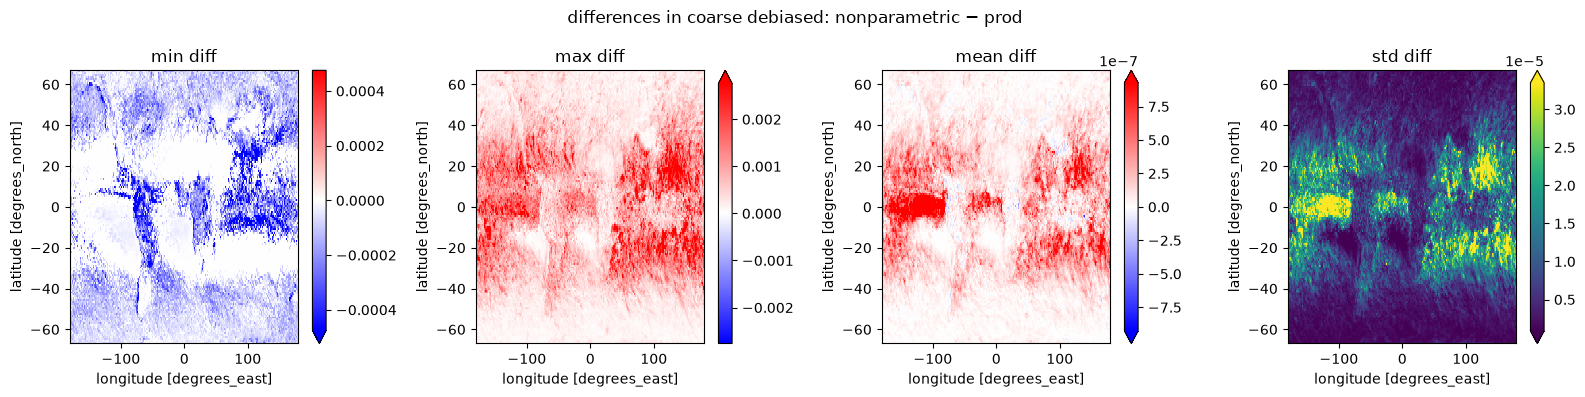

In [34]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
diff_min(nonparametric, prod_debiased_coarse).plot(ax=axes[0], robust=True, cmap="bwr", center=0)
diff_max(nonparametric, prod_debiased_coarse).plot(ax=axes[1], robust=True, cmap="bwr", center=0)
diff_mean(nonparametric, prod_debiased_coarse).plot(ax=axes[2], robust=True, cmap="bwr", center=0)
diff_std(nonparametric, prod_debiased_coarse).plot(ax=axes[3], robust=True, cmap="viridis")
for ax, title in zip(axes, ["min diff", "max diff", "mean diff", "std diff"]):
    ax.set_title(title)
fig.suptitle("differences in coarse debiased: nonparametric − prod")
plt.tight_layout()
plt.show()

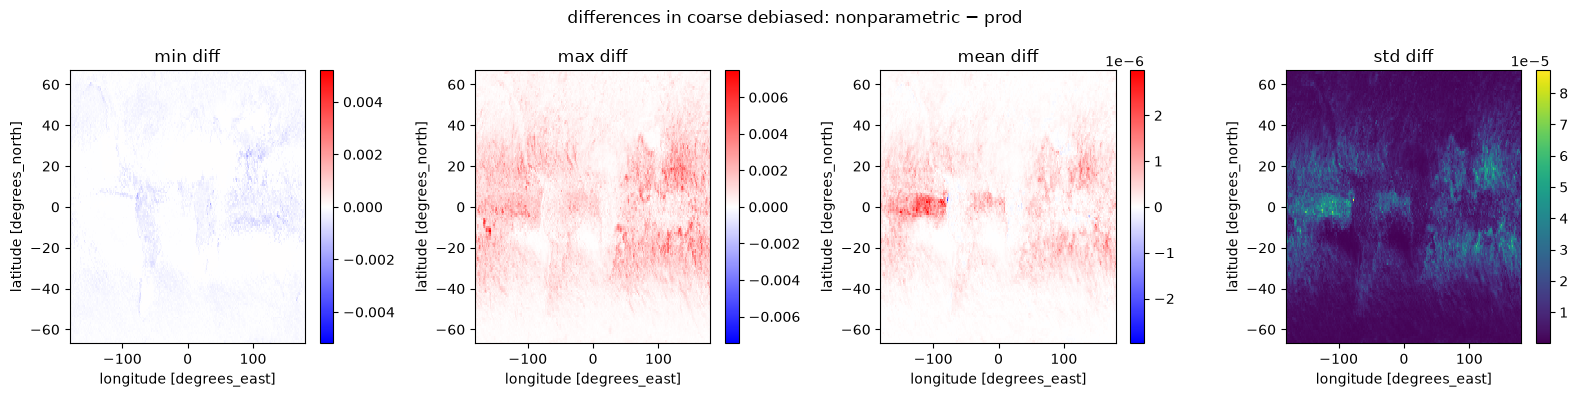

In [35]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
diff_min(nonparametric, prod_debiased_coarse).plot(ax=axes[0], robust=False, cmap="bwr", center=0)
diff_max(nonparametric, prod_debiased_coarse).plot(ax=axes[1], robust=False, cmap="bwr", center=0)
diff_mean(nonparametric, prod_debiased_coarse).plot(ax=axes[2], robust=False, cmap="bwr", center=0)
diff_std(nonparametric, prod_debiased_coarse).plot(ax=axes[3], robust=False, cmap="viridis")
for ax, title in zip(axes, ["min diff", "max diff", "mean diff", "std diff"]):
    ax.set_title(title)
fig.suptitle("differences in coarse debiased: nonparametric − prod")
plt.tight_layout()
plt.show()

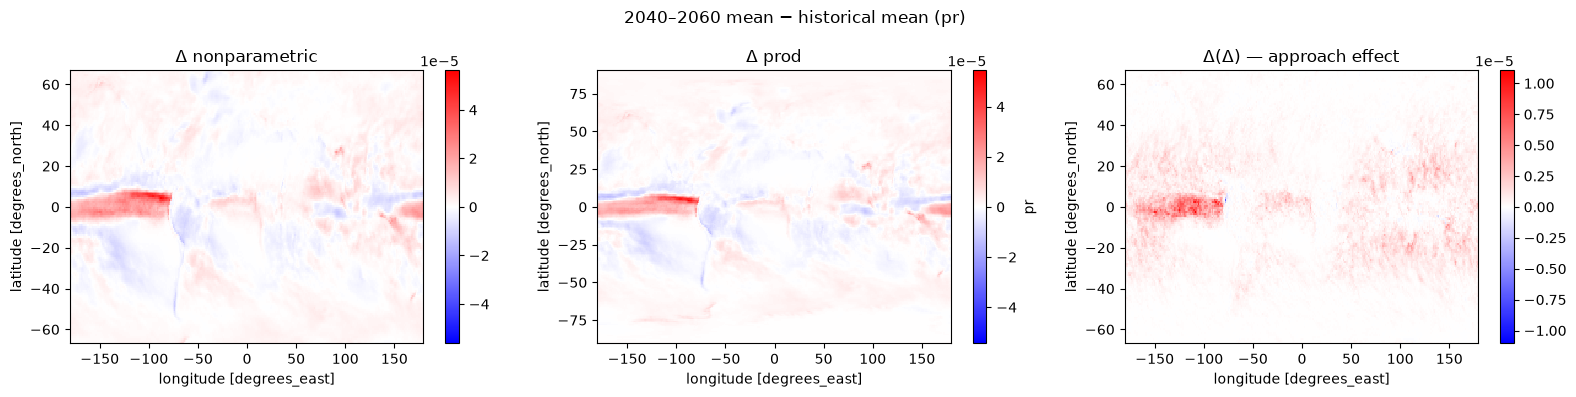

In [39]:
# ── 3. Climate-change delta (2070–2099 mean − historical mean) per approach ───
# debiased_coarse (Stage 2) is reused as "historical" for both approaches: Stage 2's
# _apply_bias_correction always collapses nonparametric_hybrid* to plain nonparametric
# (modeled historical never falls outside its own range), so it's approach-invariant.
HISTORICAL_PERIOD = slice("1984", "2014")
FUTURE_PERIOD = slice("2040", "2060")
assert nonparametric["time"].max().values >= np.datetime64(f"{FUTURE_PERIOD.stop}-12-31"), (
    f"scenario data only runs through {nonparametric['time'].max().values} — extend "
    "predict_period_end past 2099 in the config cell, rerun Stage 3, and re-save/re-load "
    "ds_dict before this cell has data for 2070-2099."
)


def cc_delta(da, historical_period=HISTORICAL_PERIOD, future_period=FUTURE_PERIOD):
    return da.sel(time=FUTURE_PERIOD).mean("time") - da.sel(time=HISTORICAL_PERIOD).mean("time")


delta_nonparametric = cc_delta(nonparametric)
delta_prod = cc_delta(prod_debiased_coarse)
delta_diff = delta_nonparametric - delta_prod

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
delta_nonparametric.plot(ax=axes[0], robust=False, cmap="bwr", center=0)
delta_prod.plot(ax=axes[1], robust=False, cmap="bwr", center=0)
delta_diff.plot(ax=axes[2], robust=False, cmap="bwr", center=0)
for ax, title in zip(axes, ["Δ nonparametric", "Δ prod", "Δ(Δ) — approach effect"]):
    ax.set_title(title)
fig.suptitle(
    f"{FUTURE_PERIOD.start}–{FUTURE_PERIOD.stop} mean − historical mean ({config.variable})"
)
plt.tight_layout()
plt.show()

## Pixel-level comparison: nonparametric vs prod_debiased_coarse

Select 10 pixels spread around the globe where `nonparametric` and
`prod_debiased_coarse` diverge most (ranked jointly on mean, min, and max
diff), then plot both series at each pixel to see how the values changed.

In [40]:
# ── Select 10 pixels with large nonparametric − prod_debiased_coarse differences ──
# Rank pixels by |mean diff|, |min diff|, and |max diff| independently, combine
# the ranks, then greedily walk the ranking and keep a pixel only if it's at
# least MIN_SEPARATION_DEG away (lat or lon) from every pixel already picked —
# that keeps the 10 spread around the globe instead of clustered in one hot spot.
mean_diff_map = diff_mean(nonparametric, prod_debiased_coarse)
min_diff_map = diff_min(nonparametric, prod_debiased_coarse)
max_diff_map = diff_max(nonparametric, prod_debiased_coarse)

diff_stack = (
    xr.Dataset({"mean": abs(mean_diff_map), "min": abs(min_diff_map), "max": abs(max_diff_map)})
    .stack(pixel=("lat", "lon"))
    .dropna("pixel")
)
diff_stack = diff_stack.load()

In [41]:
combined_rank = sum(diff_stack[v].rank("pixel") for v in ["mean", "min", "max"])
ranked_pixels = combined_rank.sortby(combined_rank, ascending=False)["pixel"].values

MIN_SEPARATION_DEG = 10  # minimum lat/lon spacing between selected pixels
N_PIXELS = 10
selected = []
for lat, lon in ranked_pixels:
    if all(
        abs(lat - s_lat) >= MIN_SEPARATION_DEG or abs(lon - s_lon) >= MIN_SEPARATION_DEG
        for s_lat, s_lon in selected
    ):
        selected.append((float(lat), float(lon)))
    if len(selected) == N_PIXELS:
        break

print(f"Selected {len(selected)} pixels:")
for lat, lon in selected:
    print(
        f"  lat={lat:6.2f}, lon={lon:7.2f}  "
        f"mean_diff={float(mean_diff_map.sel(lat=lat, lon=lon)):.4g}  "
        f"min_diff={float(min_diff_map.sel(lat=lat, lon=lon)):.4g}  "
        f"max_diff={float(max_diff_map.sel(lat=lat, lon=lon)):.4g}"
    )

Selected 10 pixels:
  lat=  7.07, lon=  73.75  mean_diff=1.033e-06  min_diff=-0.0005753  max_diff=0.002797
  lat=-10.84, lon= 148.75  mean_diff=1.117e-06  min_diff=-0.0004176  max_diff=0.00369
  lat= 11.78, lon= 113.75  mean_diff=7.129e-07  min_diff=-0.0007386  max_diff=0.003429
  lat= 12.72, lon= 128.75  mean_diff=1.08e-06  min_diff=-0.0004414  max_diff=0.003014
  lat= 13.66, lon= 150.00  mean_diff=7.853e-07  min_diff=-0.0004135  max_diff=0.004118
  lat= 26.86, lon=  91.25  mean_diff=1.044e-06  min_diff=-0.0007776  max_diff=0.002192
  lat= 27.80, lon= 127.50  mean_diff=7.82e-07  min_diff=-0.0004561  max_diff=0.002975
  lat= 22.15, lon= 112.50  mean_diff=8.827e-07  min_diff=-0.0006435  max_diff=0.002313
  lat=  6.13, lon=-115.00  mean_diff=9.433e-07  min_diff=-0.0003896  max_diff=0.00284
  lat=-12.72, lon= 132.50  mean_diff=6.64e-07  min_diff=-0.0004713  max_diff=0.00336


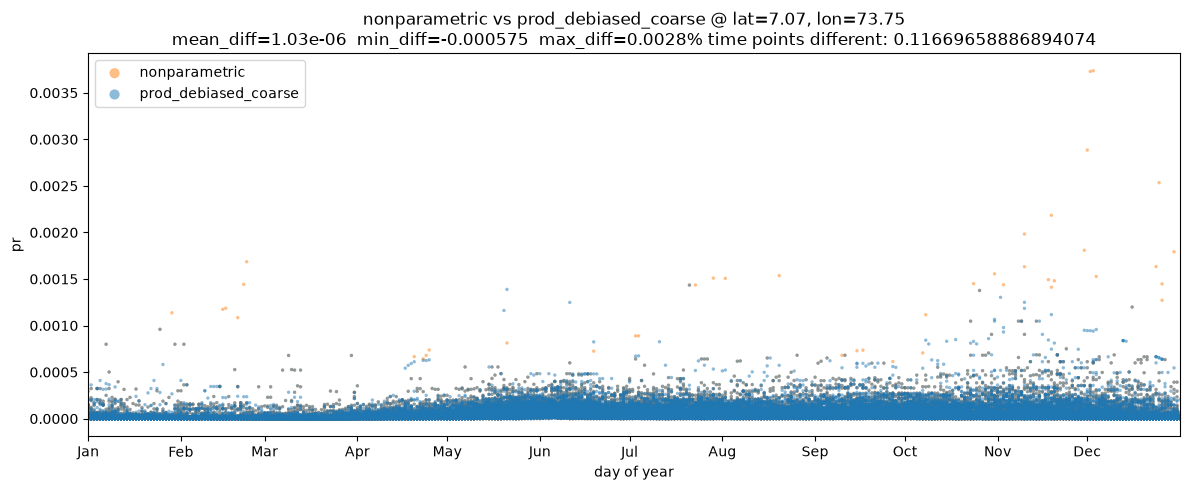

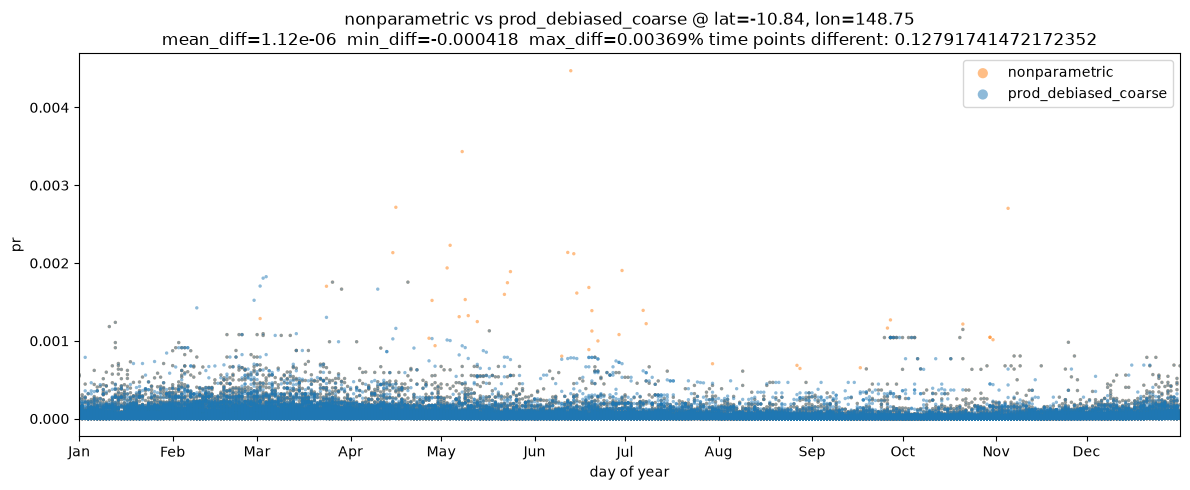

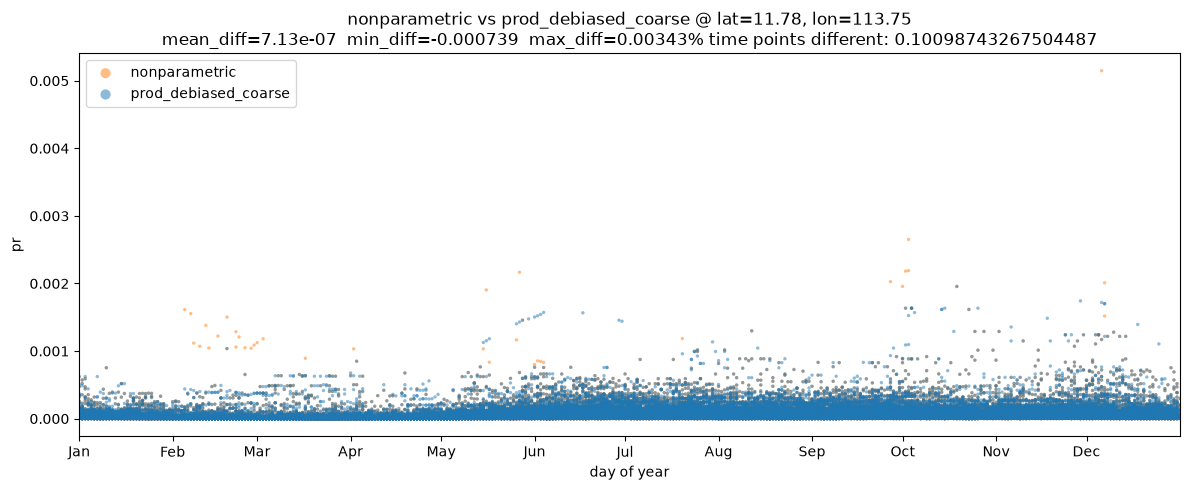

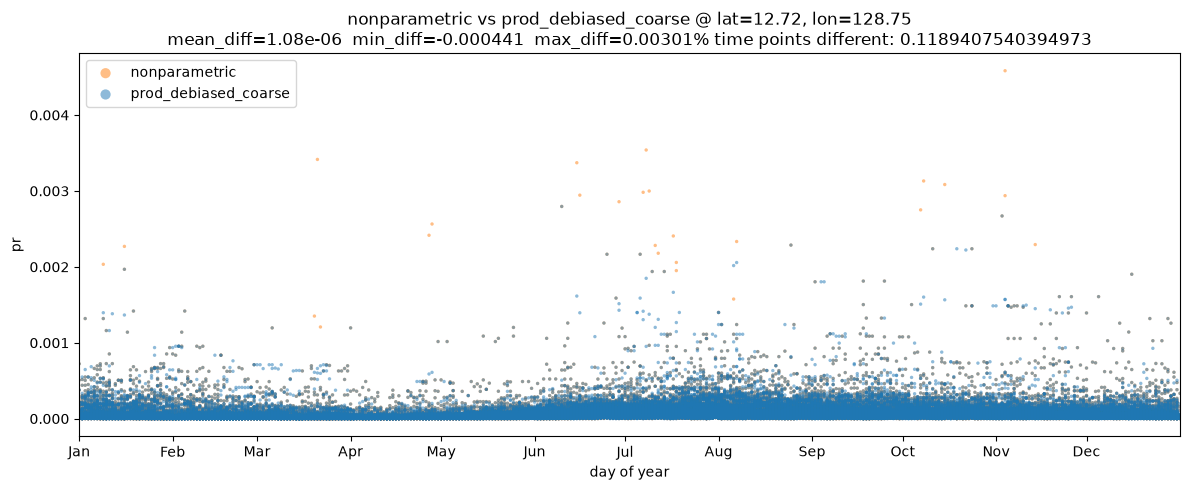

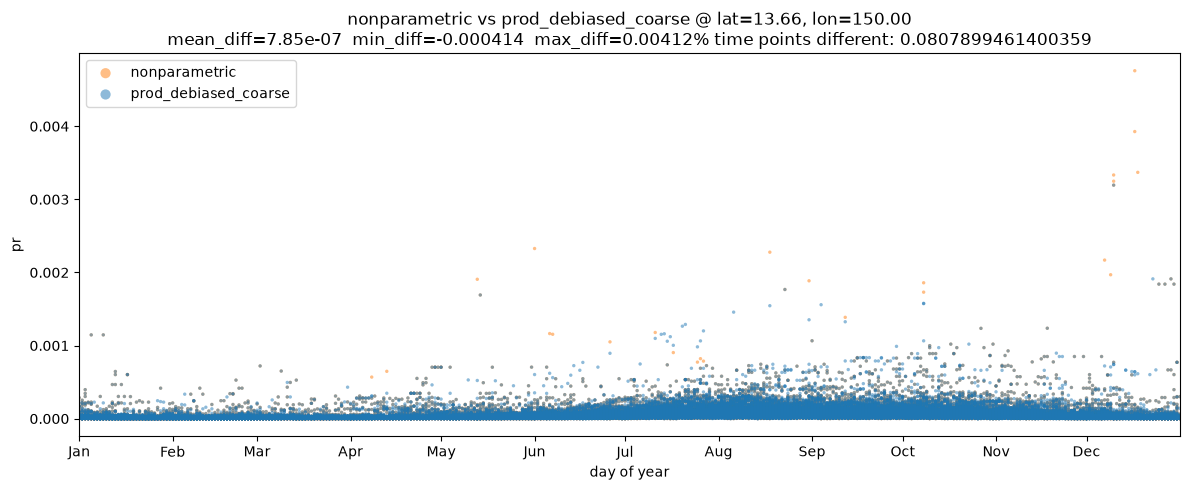

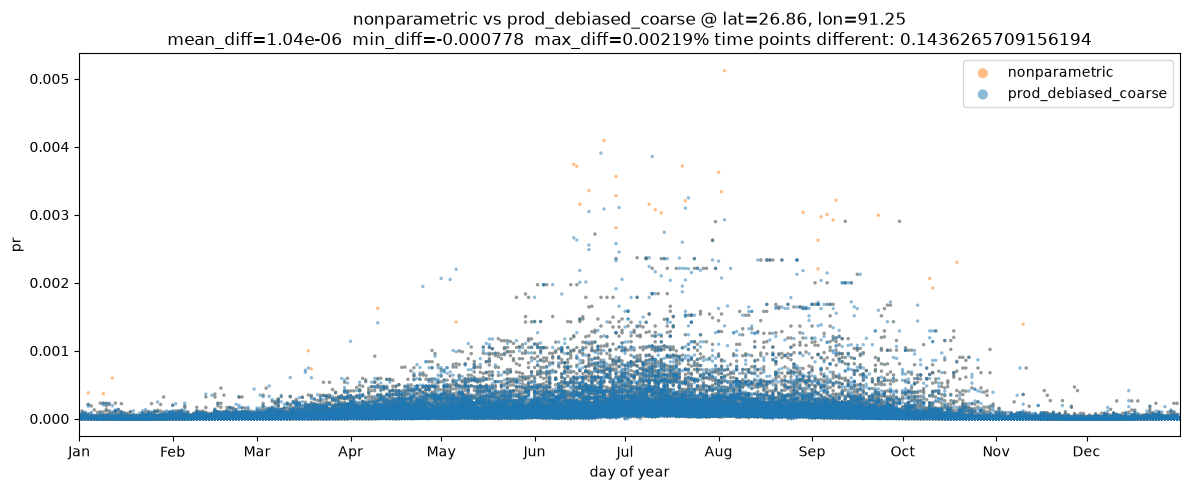

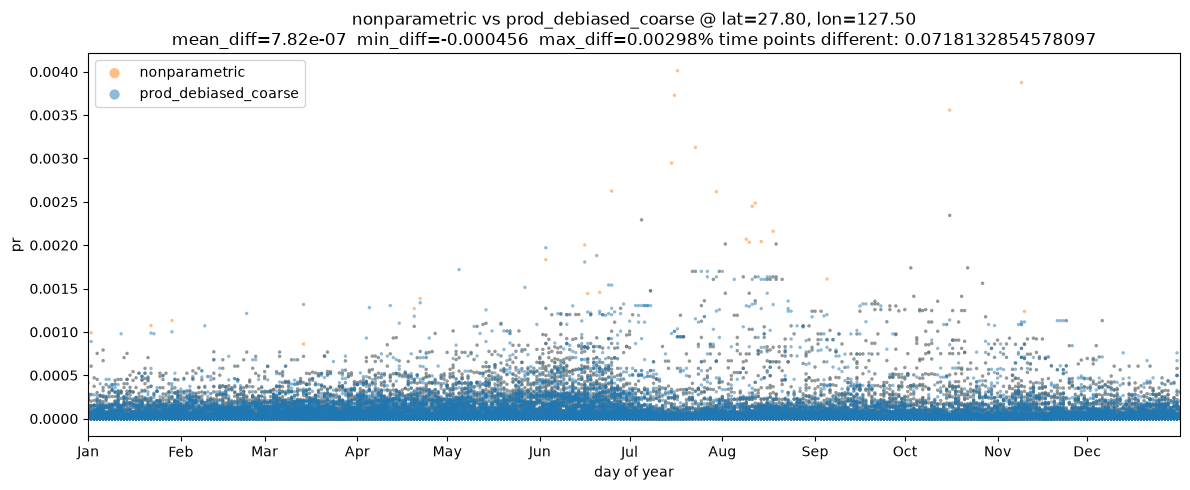

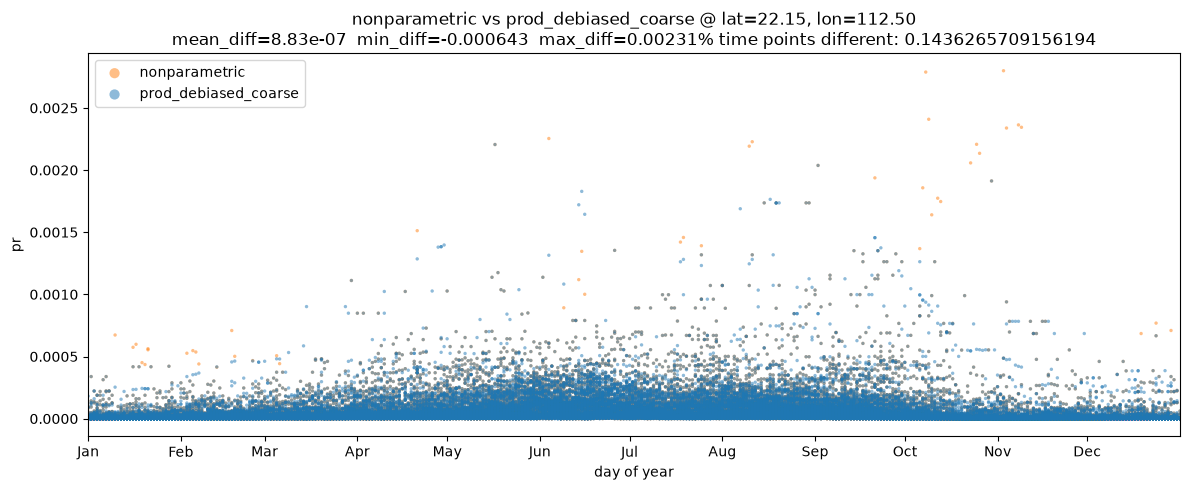

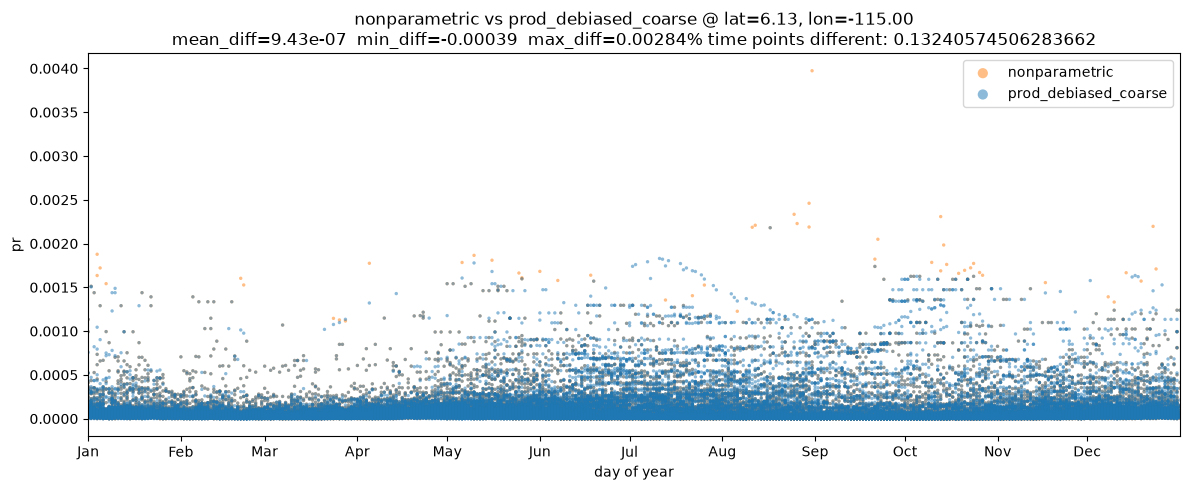

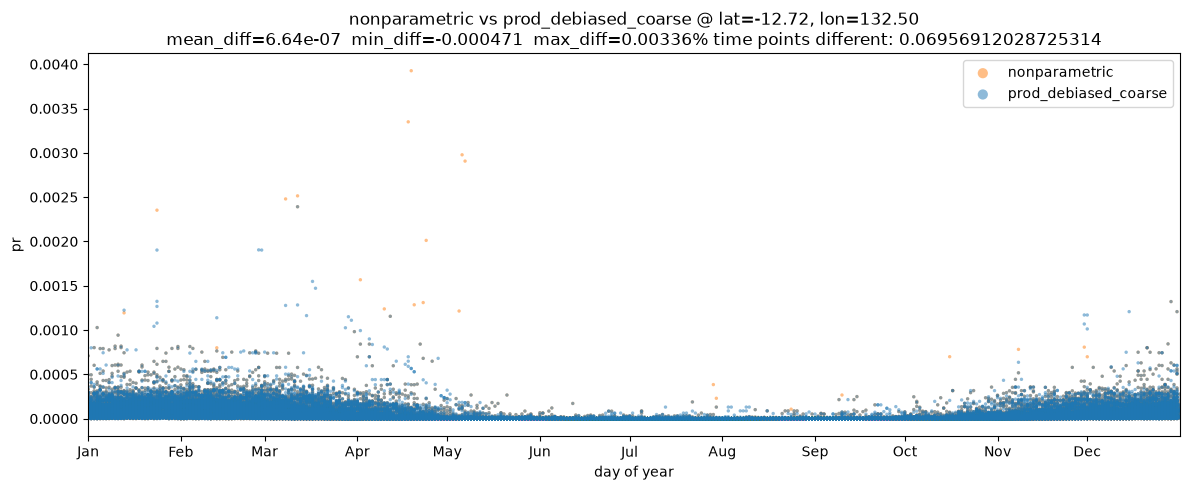

In [42]:
# ── Per-pixel scatter: nonparametric (orange) vs prod_debiased_coarse (blue) ──
_month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]

for lat, lon in selected:
    pt_nonparametric = nonparametric.sel(lat=lat, lon=lon, method="nearest").compute()
    pt_prod = prod_debiased_coarse.sel(lat=lat, lon=lon, method="nearest").compute()
    pt_nonparametric
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.scatter(
        pt_nonparametric["time"].dt.dayofyear,
        pt_nonparametric.values,
        c="tab:orange",
        s=6,
        alpha=0.5,
        edgecolors="none",
        label="nonparametric",
    )
    ax.scatter(
        pt_prod["time"].dt.dayofyear,
        pt_prod.values,
        c="tab:blue",
        s=6,
        alpha=0.5,
        edgecolors="none",
        label="prod_debiased_coarse",
    )
    ax.set_xticks(_month_starts)
    ax.set_xticklabels(_MONTH_NAMES)
    ax.set_xlim(1, 366)
    ax.set_xlabel("day of year")
    ax.set_ylabel(config.variable)
    ax.legend(markerscale=3)
    ax.set_title(
        f"nonparametric vs prod_debiased_coarse @ lat={lat:.2f}, lon={lon:.2f}\n"
        f"mean_diff={float(mean_diff_map.sel(lat=lat, lon=lon)):.3g}  "
        f"min_diff={float(min_diff_map.sel(lat=lat, lon=lon)):.3g}  "
        f"max_diff={float(max_diff_map.sel(lat=lat, lon=lon)):.3g}"
        f"% time points different: {((pt_nonparametric != pt_prod).sum() / len(pt_prod) * 100).values}"
    )
    plt.tight_layout()
    plt.show()

## Full-year time series at the 10 largest max-diff and 10 largest min-diff pixels

For the 10 pixels with the largest `max_diff_map` value and the 10 pixels with
the most negative `min_diff_map` value (nonparametric − prod_debiased_coarse),
find the calendar year containing that single extreme timestep and plot the
full year of daily data for both series — 20 plots total, two lines each.

In [43]:
# ── Top 10 max-diff and top 10 min-diff single-pixel instances ────────────────
# Rank pixels by the raw (signed) max_diff_map / min_diff_map computed above,
# take the 10 most extreme in each direction, then find the exact year each
# extreme timestep falls in (idxmax/idxmin on the pointwise nonparametric −
# prod_debiased_coarse difference) so we can pull a full calendar year of data.
max_diff_stacked = max_diff_map.stack(pixel=("lat", "lon")).dropna("pixel")
min_diff_stacked = min_diff_map.stack(pixel=("lat", "lon")).dropna("pixel")

In [44]:
top_max_pixels = max_diff_stacked.sortby(max_diff_stacked, ascending=False)[:10]

In [45]:
top_min_pixels = min_diff_stacked.sortby(min_diff_stacked, ascending=True)[:10]

In [46]:
def year_of_extreme(lat, lon, kind):
    """Calendar year containing the timestep of the max/min pointwise diff at (lat, lon)."""
    pt_diff = (
        (nonparametric - prod_debiased_coarse).sel(lat=lat, lon=lon, method="nearest").compute()
    )
    extreme_time = pt_diff.idxmax("time") if kind == "max" else pt_diff.idxmin("time")
    return int(extreme_time.dt.year)


max_instances = []
for lat, lon in top_max_pixels["pixel"].values:
    lat, lon = float(lat), float(lon)
    year = year_of_extreme(lat, lon, "max")
    max_instances.append((lat, lon, year, float(max_diff_map.sel(lat=lat, lon=lon))))

print("Top 10 max-diff instances (lat, lon, year, diff):")
for inst in max_instances:
    print(f"  lat={inst[0]:6.2f}, lon={inst[1]:7.2f}, year={inst[2]}, max_diff={inst[3]:.4g}")

min_instances = []
for lat, lon in top_min_pixels["pixel"].values:
    lat, lon = float(lat), float(lon)
    year = year_of_extreme(lat, lon, "min")
    min_instances.append((lat, lon, year, float(min_diff_map.sel(lat=lat, lon=lon))))

print("\nTop 10 min-diff instances (lat, lon, year, diff):")
for inst in min_instances:
    print(f"  lat={inst[0]:6.2f}, lon={inst[1]:7.2f}, year={inst[2]}, min_diff={inst[3]:.4g}")

Top 10 max-diff instances (lat, lon, year, diff):
  lat=-11.78, lon=-157.50, year=2057, max_diff=0.007473
  lat=-11.78, lon=-158.75, year=2057, max_diff=0.007376
  lat= -7.07, lon=-166.25, year=2047, max_diff=0.006201
  lat=-10.84, lon=-157.50, year=2057, max_diff=0.006009
  lat=-10.84, lon=-158.75, year=2057, max_diff=0.005757
  lat= 18.38, lon= 120.00, year=2052, max_diff=0.005716
  lat= -8.01, lon=-166.25, year=2047, max_diff=0.005687
  lat=-12.72, lon=-157.50, year=2057, max_diff=0.00565
  lat=-20.26, lon=  76.25, year=2047, max_diff=0.005515
  lat=  9.90, lon= 136.25, year=2044, max_diff=0.005455

Top 10 min-diff instances (lat, lon, year, diff):
  lat=  3.30, lon= -77.50, year=2045, min_diff=-0.005199
  lat=  4.24, lon= -77.50, year=2056, min_diff=-0.002933
  lat=  2.36, lon= -77.50, year=2045, min_diff=-0.001877
  lat=  1.41, lon=  35.00, year=2029, min_diff=-0.001849
  lat= 24.97, lon=  91.25, year=2054, min_diff=-0.001836
  lat=  5.18, lon= -76.25, year=2050, min_diff=-0.00176

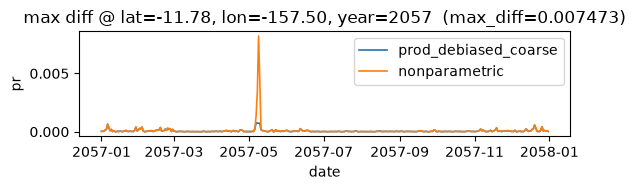

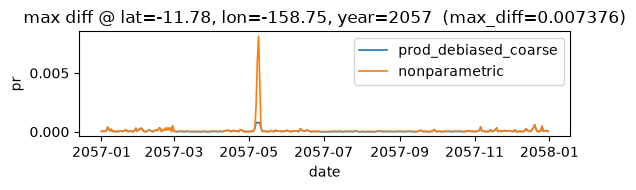

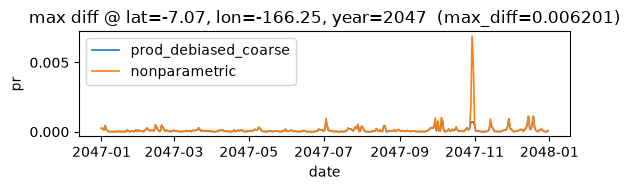

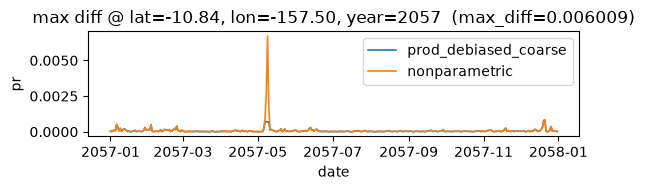

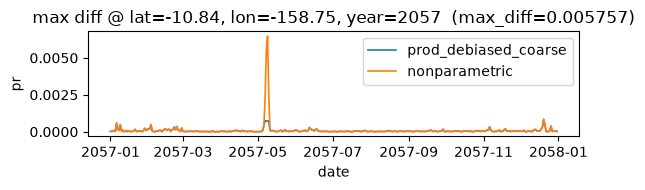

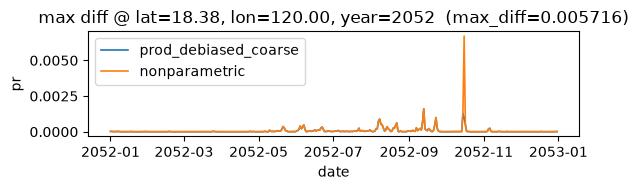

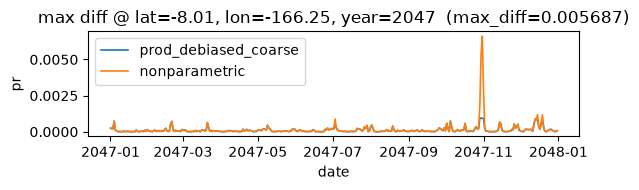

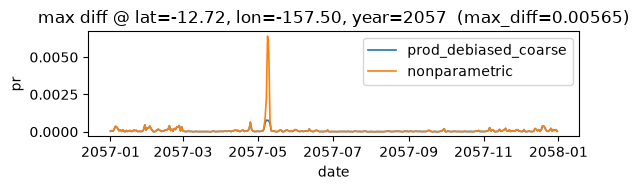

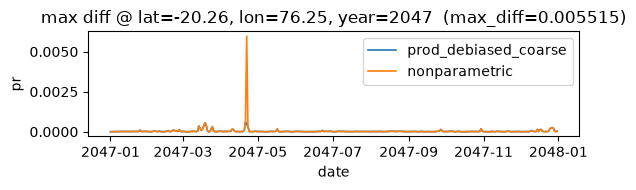

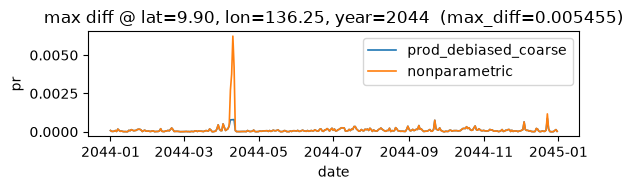

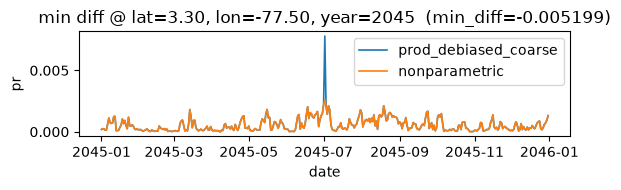

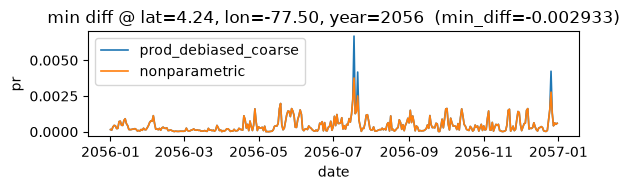

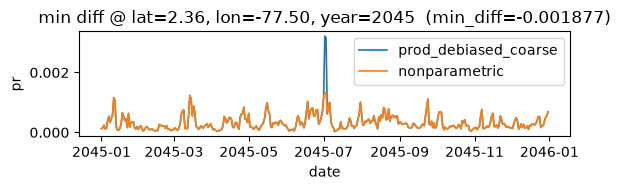

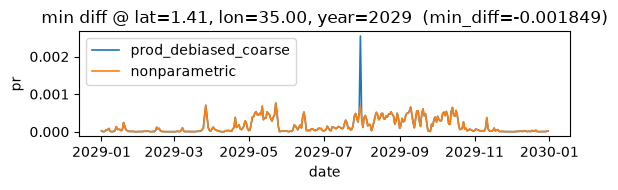

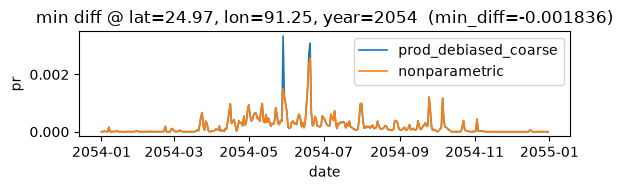

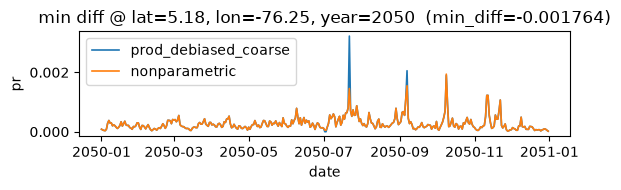

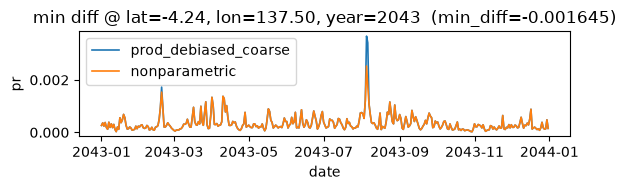

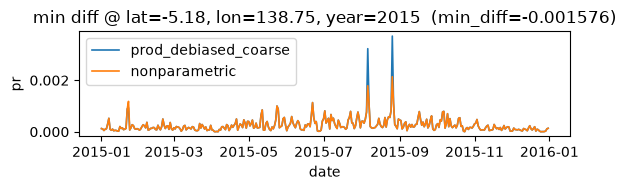

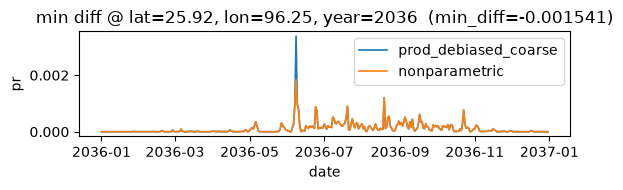

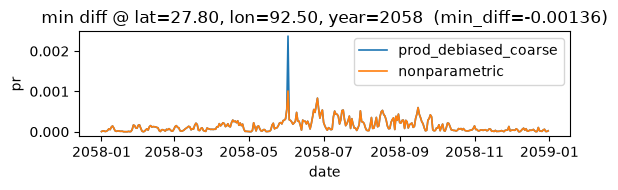

In [47]:
# ── Full-year daily time series: nonparametric (orange) vs prod_debiased_coarse (blue) ──
def plot_full_year(lat, lon, year, diff_value, kind):
    year_slice = slice(f"{year}-01-01", f"{year}-12-31")
    pt_nonparametric = (
        nonparametric.sel(lat=lat, lon=lon, method="nearest").sel(time=year_slice).compute()
    )
    pt_prod = (
        prod_debiased_coarse.sel(lat=lat, lon=lon, method="nearest").sel(time=year_slice).compute()
    )

    fig, ax = plt.subplots(figsize=(6, 2))
    ax.plot(
        pt_prod["time"],
        pt_prod.values,
        color="tab:blue",
        linewidth=1.2,
        label="prod_debiased_coarse",
    )
    ax.plot(
        pt_nonparametric["time"],
        pt_nonparametric.values,
        color="tab:orange",
        linewidth=1.2,
        label="nonparametric",
    )

    ax.set_xlabel("date")
    ax.set_ylabel(config.variable)
    ax.legend()
    ax.set_title(
        f"{kind} diff @ lat={lat:.2f}, lon={lon:.2f}, year={year}  ({kind}_diff={diff_value:.4g})"
    )
    plt.tight_layout()
    plt.show()


for lat, lon, year, diff_value in max_instances:
    plot_full_year(lat, lon, year, diff_value, "max")

for lat, lon, year, diff_value in min_instances:
    plot_full_year(lat, lon, year, diff_value, "min")

the anomaly from this unusually dark day gets tacked onto the non-parametric tail, resulting in a much darker day than in the non-parametric-hybrid approach on prod

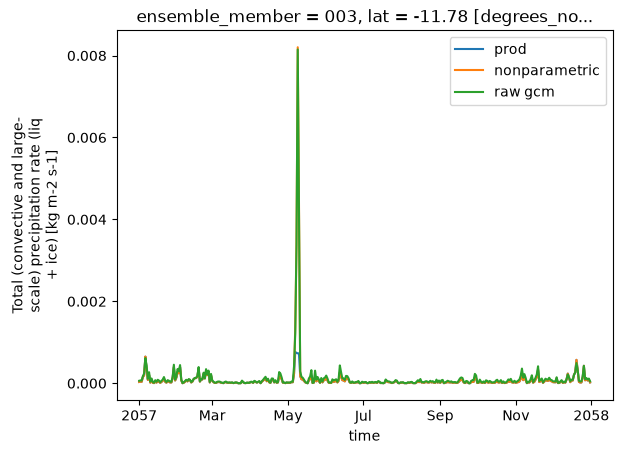

In [48]:
focus_lat = -11.78
focus_lon = -157.50
focus_year = "2057"
plt.figure()
prod_debiased_coarse.sel(time=slice(focus_year, focus_year)).sel(
    lat=focus_lat, lon=focus_lon, method="nearest"
).plot(label="prod")
nonparametric.sel(time=slice(focus_year, focus_year)).sel(
    lat=focus_lat, lon=focus_lon, method="nearest"
).plot(label="nonparametric")
model_scenario.sel(time=slice(focus_year, focus_year)).sel(
    lat=focus_lat, lon=focus_lon, method="nearest"
).plot(label="raw gcm")
plt.legend()

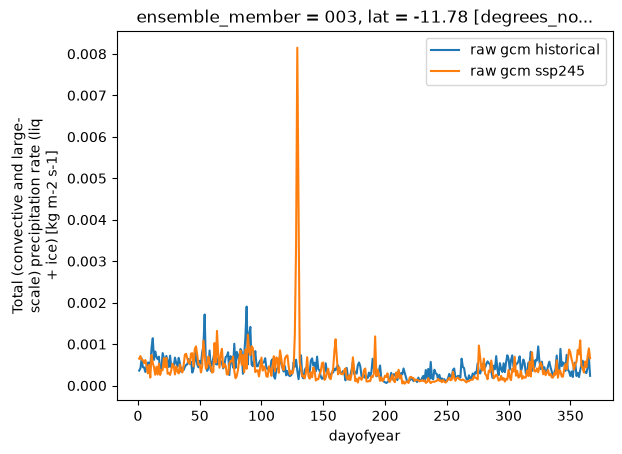

In [50]:
plt.figure()
model_hist.sel(time=HISTORICAL_PERIOD).sel(lat=focus_lat, lon=focus_lon, method="nearest").groupby(
    "time.dayofyear"
).max().plot(label="raw gcm historical")
model_scenario.sel(time=FUTURE_PERIOD).sel(lat=focus_lat, lon=focus_lon, method="nearest").groupby(
    "time.dayofyear"
).max().plot(label="raw gcm ssp245")
plt.legend()